<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>




# DBSCAN 및 HDBSCAN 클러스터링 비교
예상 소요 시간: **30**분

## 목표

이 실습을 완료하면 다음을 수행할 수 있습니다.

* scikit-learn을 사용하여 실제 데이터에 DBSCAN 및 HDBSCAN 클러스터링 모델을 구현합니다.
* 두 모델의 성능을 비교합니다.
<p style="text-align:center">
<a href="https://skills.network" target="_blank">
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network logo">
</a>
</p>

## Introduction
In this lab, you'll create two clustering models using data curated by StatCan containing the names, types, and locations of
cultural and art facilities across Canada.
We'll focus on the museum locations provided across Canada.

#### Data source: The Open Database of Cultural and Art Facilities (ODCAF)

A collection of open data containing the names, types, and locations of cultural and art facilities across Canada. 
It is released under the Open Government License - Canada.
The different types of facilities are labeled under 'ODCAF_Facility_Type'.

#### Landing page:
https://www.statcan.gc.ca/en/lode/databases/odcaf

#### link to zip file:
https://www150.statcan.gc.ca/n1/en/pub/21-26-0001/2020001/ODCAF_V1.0.zip?st=brOCT3Ry


## 소개
이 실습에서는 StatCan에서 큐레이션한 데이터를 사용하여 두 가지 클러스터링 모델을 만들어 보겠습니다. 이 데이터에는 캐나다 전역의 문화 및 예술 시설의 이름, 유형 및 위치가 포함되어 있습니다.

캐나다 전역에서 제공되는 박물관 위치에 중점을 둘 것입니다.

#### 데이터 출처: 문화 및 예술 시설 개방형 데이터베이스(ODCAF)

캐나다 전역의 문화 및 예술 시설의 이름, 유형 및 위치를 포함하는 개방형 데이터 모음입니다.
캐나다 오픈 정부 라이선스에 따라 배포됩니다.
다양한 유형의 시설은 'ODCAF_Facility_Type'으로 표시됩니다.

#### 랜딩 페이지:
https://www.statcan.gc.ca/en/lode/databases/odcaf

#### zip 파일 링크:
https://www150.statcan.gc.ca/n1/en/pub/21-26-0001/2020001/ODCAF_V1.0.zip?st=brOCT3Ry

## Import the required libraries


In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install hdbscan==0.8.40
!pip install geopandas==1.0.1
!pip install contextily==1.6.2
!pip install shapely==2.0.6

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler

# geographical tools
import geopandas as gpd  # pandas dataframe-like geodataframes for geographical data
import contextily as ctx  # used for obtianing a basemap of Canada
from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

## Download the Canada map for reference

To get a proper context of the final output of this lab, you need a reference map of Canada. Execute the cell below to extract the same to this lab environment.


## 참고용으로 캐나다 지도를 다운로드하세요.

이 랩의 최종 출력 결과를 제대로 이해하려면 캐나다 참조 지도가 필요합니다. 아래 셀을 실행하여 이 랩 환경에 동일한 지도를 추출하세요.

In [17]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref: # ZIP 파일을 메모리에서 열기
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist(): # `zip_ref.namelist()`**: ZIP 안의 모든 파일 이름 목록
        if file_name.endswith('.tif'):  # Check if it's a TIFF file #파일 이름이 '.tif'로 끝나는지 확인
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)              #파일을 압축 해제해서 저장
            print(f"Downloaded and extracted: {file_name}") #어떤 파일을 추출했는지 출력

Downloaded and extracted: Canada.tif


## Include a plotting function
The code for a helper function is provided to help you plot your results. Although you don't need to worry about the details, it's quite instructive as it uses a geopandas dataframe and a basemap to plot coloured cluster points on a map of Canada.


## 플로팅 함수 포함
결과를 플로팅하는 데 도움이 되는 도우미 함수 코드가 제공됩니다. 세부적인 내용은 신경 쓰지 않아도 되지만, 지오판다 데이터프레임과 베이스맵을 사용하여 캐나다 지도에 색상이 지정된 클러스터 지점을 표시하므로 매우 유용합니다.

In [18]:
# Write a function that plots clustered locations and overlays them on a basemap.

def plot_clustered_locations(df,  title='Museums Clustered by Proximity'): # 함수 선언
    """
    Plots clustered locations and overlays on a basemap.
    
    Parameters:
    - df: DataFrame containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    """
    
    # Load the coordinates intto a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")
    # gpd.GeoDataFrame(): 지리 데이터를 다루는 특별한 데이터프레임
    # 지리 위치청보를 위도와 경도로 추가
    # gpd.points_from_xy() 경도 위도를 점으로 변환
    # 좌표 시스템 crs="EPSG:4326"



    # Reproject to Web Mercator to align with basemap 
    gdf = gdf.to_crs(epsg=3857)
    #.to_crs(epsg=3857): Web Mercator 좌표계로 변환


    
    # Create the plot # 차트 준비
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Separate non-noise, or clustered points from noise, or unclustered points
    # 노이즈와 클러스터 분리
    non_noise = gdf[gdf['Cluster'] != -1] # 클러스터
    noise = gdf[gdf['Cluster'] == -1] # 노이즈
    
    # Plot noise points
    # 노이즈 포인트
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
    
    # Plot clustered points, colured by 'Cluster' number
    # 클러스터 포인트
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)
    
    # Add basemap of  Canada
    # ctx.add_basemap(): 배경 지도 추가
    # source='./Canada.tif': 앞에서 다운로드한 캐나다 지도
    # zoom=4: 확대 수준
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)
    
    # Format plot
    plt.title(title, )
    plt.xlabel('Longitude', )
    plt.ylabel('Latitude', )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    
    # Show the plot
    plt.show()

## Explore the data and extract what you need from it
## 데이터를 탐색하고 필요한 정보를 추출하세요


#### Start by loading the data set into a Pandas DataFrame and displaying the first few rows.

#### 먼저 데이터 세트를 Pandas DataFrame에 로드하고 처음 몇 행을 표시합니다.

In [19]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
df = pd.read_csv(url, encoding = "ISO-8859-1")

In [20]:
df.head()

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766


### Exercise 1. Explore the table. What do missing values look like in this data set?

### 연습 1. 표를 살펴보세요. 이 데이터 세트에서 누락된 값은 어떻게 표시되나요?

<details><summary>Click here for the solution</summary>
Strings consisting of two dots '..' indicate missing values. There miight still be empty fields, or NaNs.
</details>

<details><summary>해결책을 보려면 여기를 클릭하세요</summary>
두 개의 점('..')으로 구성된 문자열은 누락된 값을 나타냅니다. 빈 필드나 NaN 값이 있을 수 있습니다.
</details>

### Exercise 2. Display the facility types and their counts.

### 연습문제 2. 시설 유형과 개수를 표시하세요.

In [21]:
# your code here
# .value_counts(): 각 값이 몇 번 나오는지 세기

print(df.ODCAF_Facility_Type.value_counts())


ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64


<details><summary>Click here for the solution</summary>
    
```python
df.ODCAF_Facility_Type.value_counts()
```

</details>


### Exercise 3. Filter the data to only include museums.
Check your results. Did you get as many as you expected?

### 연습 3. 박물관만 포함되도록 데이터를 필터링하세요.
결과를 확인하세요. 예상한 만큼 결과가 나왔나요?


In [22]:
# your code here
df = df[df.ODCAF_Facility_Type == 'museum']
df.ODCAF_Facility_Type.value_counts()



ODCAF_Facility_Type
museum    1938
Name: count, dtype: int64

<details><summary>Click here for the solution</summary>

```python
df = df[df.ODCAF_Facility_Type == 'museum']
df.ODCAF_Facility_Type.value_counts()
```

</details>


### Exercise 4.  Select only the Latitude and Longitude features as inputs to our clustering problem.
Also, display information about the coordinates like counts and data types.


### 연습문제 4. 클러스터링 문제의 입력으로 위도와 경도 피처만 선택합니다.
또한, 개수 및 데이터 유형과 같은 좌표 정보를 표시합니다.

In [23]:
# your code here
df = df[['Latitude', 'Longitude']]
df.info()




<class 'pandas.core.frame.DataFrame'>
Index: 1938 entries, 1 to 7969
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Latitude   1938 non-null   object
 1   Longitude  1938 non-null   object
dtypes: object(2)
memory usage: 110.0+ KB


<details><summary>Click here for the solution</summary>

```python
df = df[['Latitude', 'Longitude']]
df.info()
```

</details>


### Exercise 5. We'll need these coordinates to be floats, not objects.
Remove any museums that don't have coordinates, and convert the remaining coordinates to floats.


### 연습문제 5. 이 좌표는 객체가 아닌 부동 소수점이어야 합니다.
좌표가 없는 박물관을 제거하고 나머지 좌표를 부동 소수점으로 변환합니다.

In [25]:
# your code here

df = df[df.Latitude != '..']
df[['Latitude', 'Longitude']] = df[['Latitude', 'Longitude']].astype('float')
print(df)


       Latitude   Longitude
1     55.264551 -127.642812
2     45.963283  -66.641902
8     49.176354 -123.112783
13    49.261938 -123.151123
15    49.889559  -97.235744
...         ...         ...
7934  43.183090  -79.224564
7936  43.690022  -79.476208
7940  43.857692  -79.361940
7968  48.422420 -123.343553
7969  48.426005 -123.369188

[1607 rows x 2 columns]


<details><summary>Click here for the solution</summary>

```python

# Remove observations with no coordinates 
df = df[df.Latitude!='..']

# Convert to float
df[['Latitude','Longitude']] = df[['Latitude','Longitude']].astype('float')
```

</details>


## Build a DBSCAN model
##### Correctly scale the coordinates for DBSCAN (since DBSCAN is sensitive to scale)

## DBSCAN 모델 구축
##### DBSCAN의 좌표를 올바르게 스케일링합니다(DBSCAN은 스케일에 민감합니다).

In [27]:
# In this case we know how to scale the coordinates. Using standardization would be an error becaues we aren't using the full range of the lat/lng coordinates.
# Since latitude has a range of +/- 90 degrees and longitude ranges from 0 to 360 degrees, the correct scaling is to double the longitude coordinates (or half the Latitudes)
coords_scaled = df.copy()
coords_scaled["Latitude"] = 2*coords_scaled["Latitude"] # 위도 값을 2배로 늘려서, 위도와 경도의 범위를 비슷하게 맞춥니다.

#실전 활용
## 이렇게 스케일링하는 이유:
### 거리 계산 정확도:
#### 클러스터링(DBSCAN 등)에서 거리 계산 시
#### 위도/경도가 공평하게 기여
### K-means 같은 알고리즘:
#### 유클리드 거리 기반 알고리즘에 필수!

### Apply DBSCAN with Euclidean distance to the scaled coordinates
In this case, reasonable neighbourhood parameters are already chosen for you. Feel free to experiment.

### 스케일된 좌표에 유클리드 거리를 적용하여 DBSCAN을 적용합니다.
이 경우, 적절한 이웃 매개변수가 이미 선택되어 있습니다. 자유롭게 실험해 보세요.


In [28]:
min_samples=3 # minimum number of samples needed to form a neighbourhood # (최소 샘플 수)
eps=1.0 # neighbourhood search radius #  이웃 탐색 반경 (얼마나 가까워야 이웃으로 보는지)
metric='euclidean' # distance measure #  metric (거리 측정 방법) ### **euclidean**: 유클리드 거리 (직선 거리)

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(coords_scaled)

### Add cluster labels to the DataFrame

### DataFrame에 클러스터 레이블 추가

In [30]:
df['Cluster'] = dbscan.fit_predict(coords_scaled)  # Assign the cluster labels # 학습+예측

# Display the size of each cluster
df['Cluster'].value_counts() #클러스터별 건수

Cluster
 4     701
 2     192
 1     181
 7     134
 3      94
-1      79
 6      30
 10     27
 8      21
 11     15
 15     13
 20     11
 16     10
 19      9
 27      8
 12      7
 24      6
 18      6
 28      6
 26      6
 14      6
 5       6
 22      4
 9       4
 13      4
 30      3
 31      3
 29      3
 0       3
 25      3
 23      3
 21      3
 17      3
 32      3
Name: count, dtype: int64

As you can see, there are two relatively large clusters and 79 points labelled as noise (-1).
### Plot the museums on a basemap of Canada, colored by cluster label.

보시다시피, 비교적 큰 클러스터 두 개와 노이즈(-1)로 표시된 79개 지점이 있습니다.
### 클러스터 레이블에 따라 색칠된 캐나다 기본 지도에 박물관을 표시하세요.

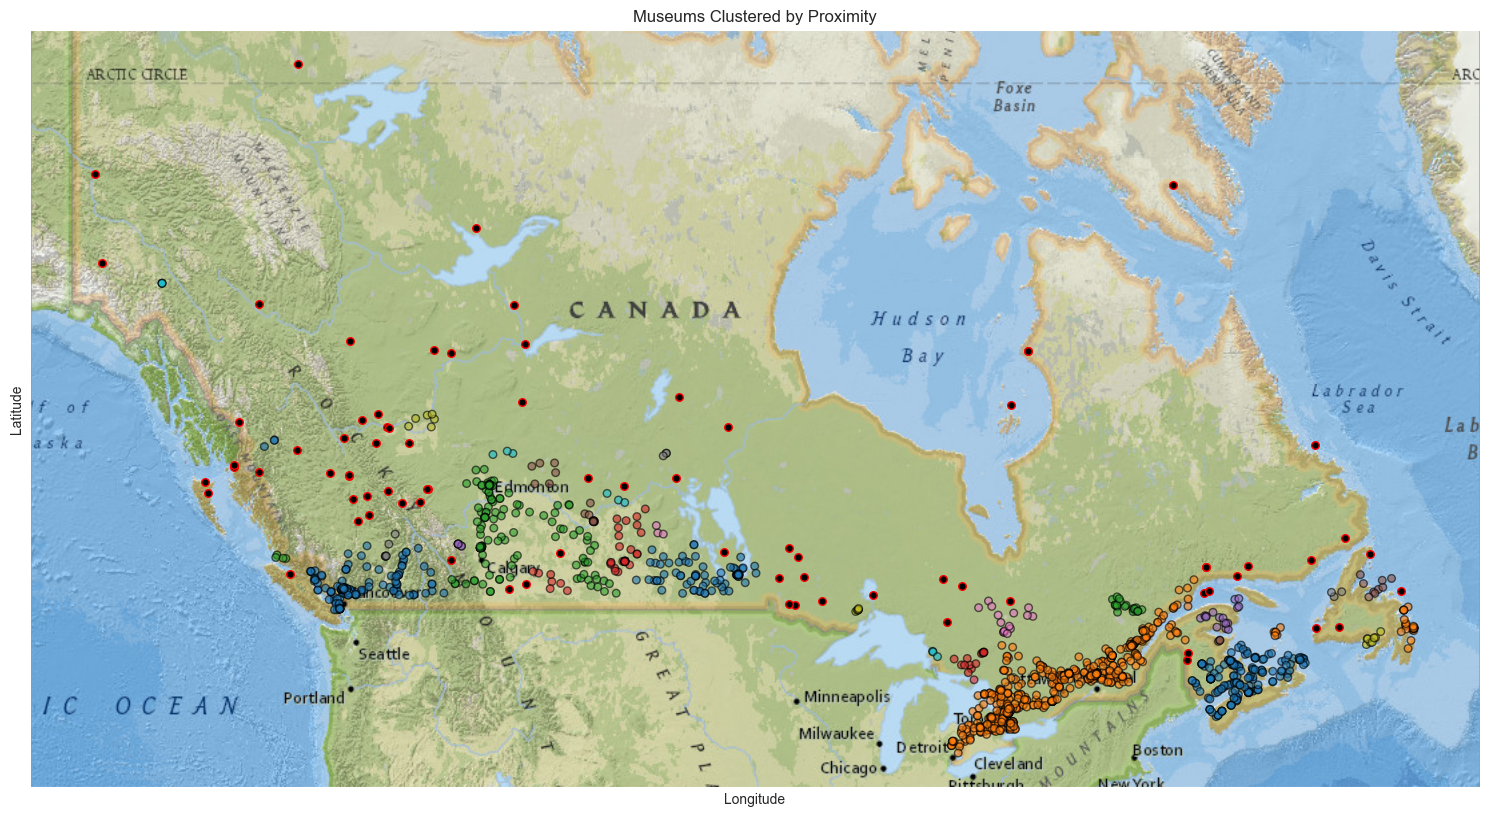

In [31]:
plot_clustered_locations(df, title='Museums Clustered by Proximity')
# df: 클러스터 정보가 들어있는 데이터프레임
# 반드시 Latitude, Longitude, Cluster 컬럼이 있어야 함!

- What do you see? 
- What size is the smallest cluster? 
- Do you think the clusters make sense in terms of what you expect to see? 
- Do you think there should be more clusters in some regions? Why?


- 무엇이 보이시나요?
- 가장 작은 클러스터의 크기는 얼마인가요?
- 예상하는 결과와 비교했을 때 클러스터가 합리적이라고 생각하시나요?
- 일부 지역에 클러스터가 더 많아야 한다고 생각하시나요? 그 이유는 무엇인가요?

One key thing to notice here is that the clusters are not uniformly dense. 

For example, the points are quite densely packed in a few regions but are relatively sparse in between. 

DBSCAN agglomerates neighboring clusters together when they are close enough. 

Let's see how a hierarchical density-based clustering algorithm like HDBSCAN performs.

여기서 주목해야 할 중요한 점은 클러스터의 밀도가 균일하지 않다는 것입니다.

예를 들어, 점들은 일부 영역에서는 상당히 조밀하게 모여 있지만, 그 사이 영역은 상대적으로 희박합니다.

DBSCAN은 서로 충분히 가까운 이웃 클러스터들을 하나로 모읍니다.

HDBSCAN과 같은 계층적 밀도 기반 클러스터링 알고리즘의 성능을 살펴보겠습니다.


## Build an HDBSCAN clustering model
At this stage, you've already loaded your data and extracted the museum coordinates into a dataframe, df.

You've also stored properly scaled coordinates as the 'coords_scaled' array.

All that remains is to:
- Fit and transform HDBSCAN to your scaled coordinates
- Extract the cluster labels
- Plot the results on the same basemap as before

Reasonable HDBSCAN parameters have been selected for you to start with.


## HDBSCAN 클러스터링 모델 구축
이 단계에서는 이미 데이터를 로드하고 박물관 좌표를 데이터프레임 df로 추출했습니다.

또한 적절하게 축척된 좌표를 'coords_scaled' 배열로 저장했습니다.

남은 작업은 다음과 같습니다.
- HDBSCAN을 축척된 좌표에 맞춰 조정하고 변환합니다.
- 클러스터 레이블을 추출합니다.
- 이전과 동일한 베이스맵에 결과를 표시합니다.

시작하기 위해 적절한 HDBSCAN 매개변수가 선택되었습니다.

#### Initialize an HDBSCAN model

#### HDBSCAN 모델을 초기화합니다


HDBSCAN = Hierarchical Density-Based Spatial Clustering of Applications with Noise
→ "계층적 밀도 기반 클러스터링"


In [32]:
min_samples=None # 최소셈플 수  없으면 자동 추천
min_cluster_size=3 #3개 기준으로 밀도개산 3개 이하면 클러스터가 아님(노이즈로 간주)
hdb = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size, metric='euclidean')  # You can adjust parameters as needed

### Exercise 6. Assign the cluster labels to your unscaled coordinate dataframe and display the counts of each cluster label.


In [33]:
# Enter code here:

# Assign labels
df['Cluster'] = hdb.fit_predict(coords_scaled)  # Another way to assign the labels

# Display the size of each cluster
df['Cluster'].value_counts()

Cluster
-1      464
 137     45
 91      39
 66      35
 84      29
       ... 
 128      3
 109      3
 40       3
 123      3
 132      3
Name: count, Length: 141, dtype: int64

<details><summary>Click here for the solution</summary>

```python
# Assign labels
df['Cluster'] = hdb.fit_predict(coords_scaled)  # Another way to assign the labels

# Display the size of each cluster
df['Cluster'].value_counts()
```


As you can see, unlike the case for DBSCAN, clusters quite uniformly sized, although there is a quite lot of noise identified.
### Exercise 7. Plot the hierarchically clustered museums on a basemap of Canada, colored by cluster label.


보시다시피, DBSCAN의 경우와 달리 클러스터 크기는 상당히 균일하지만, 상당히 많은 노이즈가 확인되었습니다.
### 연습문제 7. 캐나다 기본 지도에 계층적으로 클러스터링된 박물관을 클러스터 레이블에 따라 색칠하여 표시하세요.

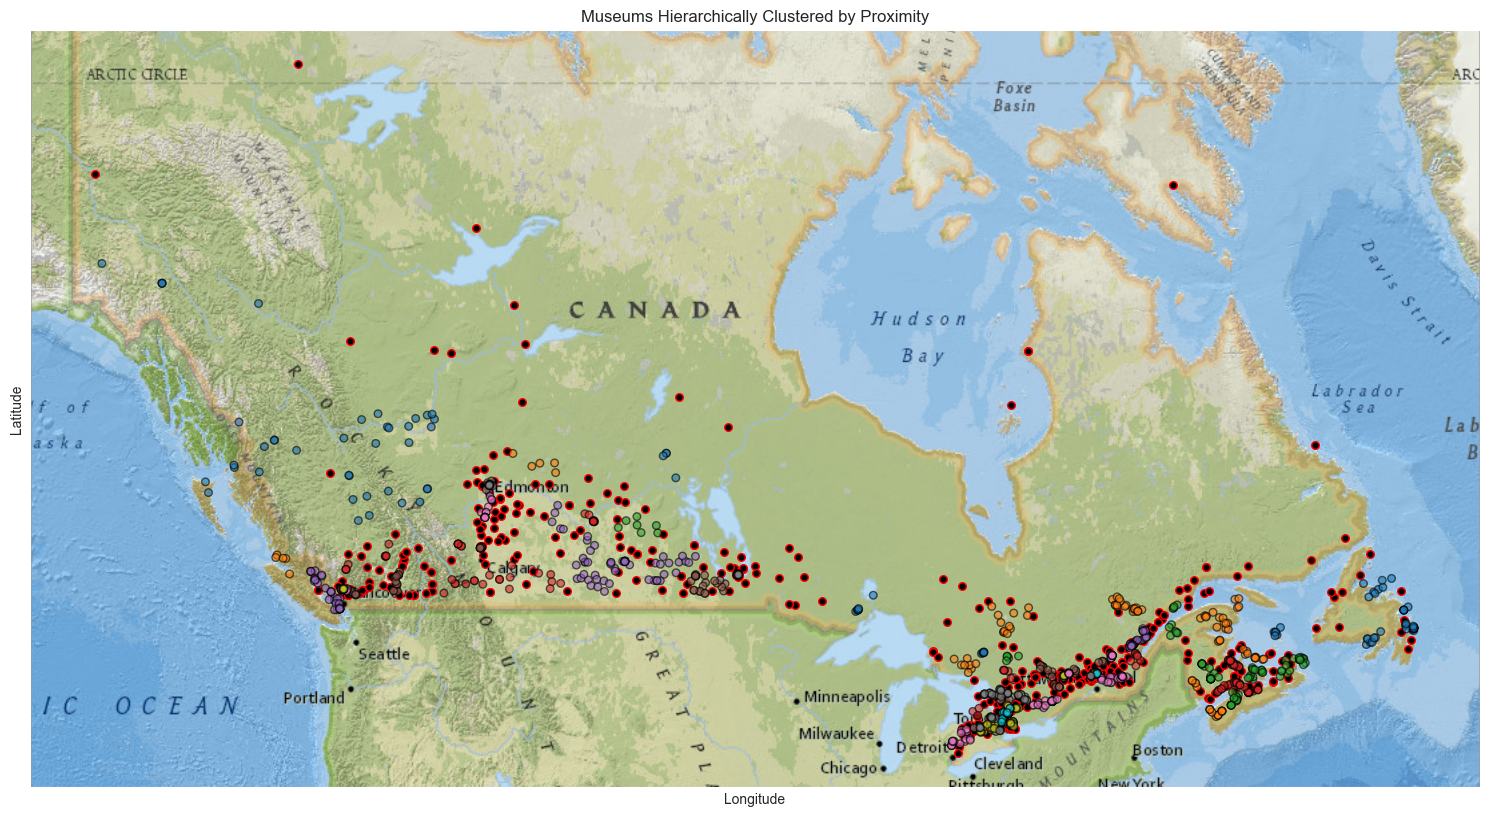

In [34]:
# Plot the museum clusters
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')

<details><summary>Click here for the solution</summary>
    
```python
# Plot the museum clusters
plot_clustered_locations(df, title='Museums Hierarchically Clustered by Proximity')
```


### Closing remarks


Take a close look at the map. 
- What's different about these results compared to DBSCAN?
- It might seem like there are more points identified as noise, but is that the case?
- Can you see the variations in density that HDBSCAN captures?
- In practice, you would want to investigate much deeper but at least you get the idea here.

지도를 자세히 살펴보세요.
- DBSCAN과 비교했을 때 이 결과의 차이점은 무엇인가요?
- 노이즈로 식별된 지점이 더 많은 것처럼 보일 수 있지만, 실제로 그럴까요?
- HDBSCAN이 포착하는 밀도 변화를 확인할 수 있나요?
- 실제로는 훨씬 더 깊이 조사해야 하지만, 적어도 여기서는 아이디어를 얻을 수 있습니다.

## Summary
Congratulations! You're ready to move on to your next lesson! In this lab, you learned how to implement DBSCAN and HDBSCAN clustering models using scikit-learn on real data from StatCan, focusing on museum locations across Canada. You also compared the performance of the two clustering techniques.

## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>


### Other Contributors

<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>


<!-- ## Changelog

| Date | Version | Changed by | Change Description |
|:------------|:------|:------------------|:---------------------------------------|
| 2024-11-05 | 1.0  | Jeff Grossman    | Update content and practice exercises |
 -->


## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>


